In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
%cd /content/gdrive/MyDrive
!pip install colorama
!pip install einops
!pip install timm

/content/gdrive/MyDrive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 66.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.0 MB/s eta 0:00:00

In [ ]:


from utils import mix
import numpy as np
import random
import logging as log
import torch
import torch.nn as nn
import torch.optim
import torch.utils.data
import torchvision.transforms as transforms
from colorama import Fore, Style
from torchsummary import summary
from utils import losses
import os
from utils import sampler
from utils import logger_dict
from utils import print_progress
from utils import training_functions
import argparse
from utils import scheduler
from utils import  dataloader
from models import build_model
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=Warning)

/content/gdrive/MyDrive/models/swin.py:728: SyntaxWarning: "is" with a literal. Did you mean "=="?
  or pretrained_layers[0] is '*'
/content/gdrive/MyDrive/models/swin.py:787: SyntaxWarning: "is" with a literal. Did you mean "=="?
  or (len(frozen_layers) > 0 and frozen_layers[0] is '*')
/content/gdrive/MyDrive/models/swin.py:798: SyntaxWarning: "is" with a literal. Did you mean "=="?
  or (len(frozen_layers) > 0 and frozen_layers[0] is '*')


In [ ]:
best_acc1 = 0
MODELS = ['vit', 'swin' , 'cait']

args = {
    "dataset": "CIFAR10",
    "image_size": 32,
    "patch_size": 4,
    "mlp_head_in": 192,
    "embed_dim": 192,
    "global_crops_scale": (0.7, 1.0),
    "local_crops_scale": (0.2, 0.5),
    "local_crops_number": 8,
    "out_dim": 1024,
    "batch_size_per_gpu": 256,
    "output_dir": "/content/gdrive/MyDrive/checkpoints",
    "datapath": "/path/to/cifar10/train/folder",
    "dist_url": "env://",
    "num_workers": 2,
    "use_bn_in_head": False,
    "norm_last_layer": False,
    "gpu":0,
    "warmup_teacher_temp": 0.04,
    "warmup_teacher_temp_epochs": 10,
    "warmup_epochs": 30,
    "epochs": 100,
    "min_lr": 1e-6,
    "optimizer": "adamw",
    "teacher_temp": 0.07,
    "use_fp16": False,
    "lr": 0.001,
    "weight_decay": 0.04,
    "weight_decay_end": 0.4,
    "momentum_teacher": 0.996,
    "freeze_last_layer": 1,
    "clip_grad": 3.0,
    "in_channels": 3,
    "qkv_bias": True,
    "drop_rate": 0,
    "drop_path_rate": 0.1,
    "saveckp_freq": 10,
    "seed": 0,
    "arch": 'vit',
    "tag": '',
    "is_SPT": False,
    "is_LSA": False,
    "pretrained_weights": "/checkpoints",
    "checkpoint_key": "teacher",
    "mix_prob": 0.5,
    "ra": 3,
    "re": 0.25,
    "re_sh": 0.4,
    "cm": True,
    "vit_mlp_ratio": 2,
    "sd": 0.1,
    "ls": True,
    "aa": True,
    "re_r1": 0.3,
    "workers": 4,
    "batch_size": 256,
    "warmup": 10,
    "resume": False,
    "no_cuda": False,
    "mu": True,
    "print_freq": 1,
    "beta": 1.0,
    "alpha": 1.0



}

print(args)

{'dataset': 'CIFAR10', 'image_size': 32, 'patch_size': 4, 'mlp_head_in': 192, 'embed_dim': 192, 'global_crops_scale': (0.7, 1.0), 'local_crops_scale': (0.2, 0.5), 'local_crops_number': 8, 'out_dim': 1024, 'batch_size_per_gpu': 256, 'output_dir': '/content/gdrive/MyDrive/checkpoints', 'datapath': '/path/to/cifar10/train/folder', 'dist_url': 'env://', 'num_workers': 2, 'use_bn_in_head': False, 'norm_last_layer': False, 'gpu': 0, 'warmup_teacher_temp': 0.04, 'warmup_teacher_temp_epochs': 10, 'warmup_epochs': 30, 'epochs': 100, 'min_lr': 1e-06, 'optimizer': 'adamw', 'teacher_temp': 0.07, 'use_fp16': False, 'lr': 0.001, 'weight_decay': 0.04, 'weight_decay_end': 0.4, 'momentum_teacher': 0.996, 'freeze_last_layer': 1, 'clip_grad': 3.0, 'in_channels': 3, 'qkv_bias': True, 'drop_rate': 0, 'drop_path_rate': 0.1, 'saveckp_freq': 10, 'seed': 0, 'arch': 'vit', 'tag': '', 'is_SPT': False, 'is_LSA': False, 'pretrained_weights': '/checkpoints', 'checkpoint_key': 'teacher', 'mix_prob': 0.5, 'ra': 3, 'r

In [ ]:
global save_path
global writer

# random seed

torch.manual_seed(args["seed"])
torch.cuda.manual_seed(args["seed"])
torch.cuda.manual_seed_all(args["seed"])  # if you are using multi-GPU.
np.random.seed(args["seed"])  # Numpy module.
random.seed(args["seed"])  # Python random module.
torch.manual_seed(args["seed"])
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

model_name = args["arch"]

if not args["is_SPT"]:
    model_name += "-Base"
else:
    print("spt present")
    model_name += "-SPT"

if args["is_LSA"]:
    print("lsa present")
    model_name += "-LSA"

model_name += f"-{args['tag']}-{args['dataset']}-LR[{args['lr']}]-Seed{args['seed']}"
save_path = os.path.join(os.getcwd(), 'save_finetuned', model_name)
if save_path:
    os.makedirs(save_path, exist_ok=True)

writer = SummaryWriter(os.path.join(os.getcwd(), 'tensorboard', model_name))

# logger

log_dir = os.path.join(save_path, 'history.csv')
logger = log.getLogger(__name__)
formatter = log.Formatter('%(message)s')
streamHandler = log.StreamHandler()
fileHandler = log.FileHandler(log_dir, 'a')
streamHandler.setFormatter(formatter)
fileHandler.setFormatter(formatter)
logger.addHandler(streamHandler)
logger.addHandler(fileHandler)
logger.setLevel(level=log.DEBUG)


global logger_dict
global keys

logger_dict = logger_dict.Logger_dict(logger, save_path)
keys = ['T Loss', 'T Top-1', 'V Loss', 'V Top-1']

In [ ]:
import os
from colorama import Fore, Style
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision
import torch


def datainfo(logger, args):
    if args["dataset"] == 'CIFAR10':
        print(Fore.YELLOW+'*'*80)
        logger.debug('CIFAR10')
        print('*'*80 + Style.RESET_ALL)
        n_classes = 10
        img_mean, img_std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        img_size = 32

    elif args["dataset"] == 'CIFAR100':
        print(Fore.YELLOW+'*'*80)
        logger.debug('CIFAR100')
        print('*'*80 + Style.RESET_ALL)
        n_classes = 100
        img_mean, img_std = (0.5070, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)
        img_size = 32

    elif args["dataset"] == 'SVHN':
        print(Fore.YELLOW+'*'*80)
        logger.debug('SVHN')
        print('*'*80 + Style.RESET_ALL)
        n_classes = 10
        img_mean, img_std = (0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)
        img_size = 32

    elif args["dataset"] == 'Tiny-Imagenet':
        print(Fore.YELLOW+'*'*80)
        logger.debug('T-IMNET')
        print('*'*80 + Style.RESET_ALL)
        n_classes = 200
        img_mean, img_std = (0.4802, 0.4481, 0.3975), (0.2770, 0.2691, 0.2821)
        img_size = 64


    elif args["dataset"] == 'CINIC':
        print(Fore.YELLOW+'*'*80)
        logger.debug('CINIC')
        print('*'*80 + Style.RESET_ALL)
        n_classes = 10
        img_mean, img_std =(0.47889522, 0.47227842, 0.43047404),(0.24205776, 0.23828046, 0.25874835)
        img_size = 32

    data_info = dict()
    data_info['n_classes'] = n_classes
    data_info['stat'] = (img_mean, img_std)
    data_info['img_size'] = img_size

    return data_info

def dataload(args, augmentations, normalize, data_info):
    if args["dataset"] == 'CIFAR10':
        train_dataset = datasets.CIFAR10(
            root=args["datapath"], train=True, download=True, transform=augmentations)

        val_dataset = datasets.CIFAR10(
            root=args["datapath"], train=False, download=True, transform=transforms.Compose([
            transforms.Resize(data_info['img_size']),
            transforms.ToTensor(),
            *normalize]))

    elif args["dataset"] == 'CIFAR100':

        train_dataset = datasets.CIFAR100(
            root=args["datapath"], train=True, download=True, transform=augmentations)
        val_dataset = datasets.CIFAR100(
            root=args["datapath"], train=False, download=True, transform=transforms.Compose([
            transforms.Resize(data_info['img_size']),
            transforms.ToTensor(),
            *normalize]))

    elif args["dataset"] == 'SVHN':

        train_dataset = datasets.SVHN(
            root=args["datapath"], split='train', download=True, transform=augmentations)
        val_dataset = datasets.SVHN(
            root=args["datapath"], split='test', download=True, transform=transforms.Compose([
            transforms.Resize(data_info['img_size']),
            transforms.ToTensor(),
            *normalize]))

    elif args["dataset"] == 'Tiny-Imagenet':
        train_dataset = datasets.ImageFolder(
            root=os.path.join(args["datapath"], 'train'), transform=augmentations)
        val_dataset = datasets.ImageFolder(
            root=os.path.join(args["datapath"], 'val'),
            transform=transforms.Compose([
            transforms.Resize(data_info['img_size']), transforms.ToTensor(), *normalize]))

    elif args["dataset"] == 'CINIC':
        train_dataset = torchvision.datasets.ImageFolder(root=os.path.join(args["datapath"], 'train'), transform=augmentations)
        val_dataset = torchvision.datasets.ImageFolder(root=os.path.join(args["datapath"], 'val'),
                      transform=transforms.Compose([
                      transforms.Resize((data_info['img_size'],data_info['img_size'])), transforms.ToTensor(), *normalize]))


    return train_dataset, val_dataset

In [ ]:
from models.vit import VisionTransformer
from models.swin import SwinTransformer
from models.cait import cait_models
from functools import partial
from torch import nn


def create_model(img_size, n_classes, args):

    if args["arch"] == "vit":
        patch_size = 4 if img_size == 32 else 8   #4 if img_size = 32 else 8
        model = VisionTransformer(img_size=[img_size],
            patch_size=args["patch_size"],
            in_chans=3,
            num_classes=n_classes,
            embed_dim=192,
            depth=9,
            num_heads=12,
            mlp_ratio=args["vit_mlp_ratio"],
            qkv_bias=True,
            drop_path_rate=args["sd"],
            norm_layer=partial(nn.LayerNorm, eps=1e-6))

    elif args["arch"] == 'cait':
        patch_size = 4 if img_size == 32 else 8
        model = cait_models(
        img_size= img_size,patch_size=patch_size, embed_dim=192, depth=24, num_heads=4, mlp_ratio=args["vit_mlp_ratio"],
        qkv_bias=True,num_classes=n_classes,drop_path_rate=args["sd"],norm_layer=partial(nn.LayerNorm, eps=1e-6),
        init_scale=1e-5,depth_token_only=2)


    elif args["arch"] =='swin':

        mlp_ratio = args["vit_mlp_ratio"]
        window_size = 4
        patch_size = 2 if img_size==32 else 4

        model = SwinTransformer(img_size=img_size,
        window_size=window_size, patch_size=patch_size, embed_dim=96, depths=[2, 6, 4], num_heads=[3, 6, 12],num_classes=n_classes,
       	mlp_ratio=mlp_ratio, qkv_bias=True, drop_path_rate=args["sd"])

    else:
        NotImplementedError("Model architecture not implemented . . .")


    return model

In [ ]:
torch.cuda.set_device(args["gpu"])

data_info = datainfo(logger, args)

model = create_model(data_info['img_size'], data_info['n_classes'], args)

model.cuda(args["gpu"])

print(Fore.GREEN+'*'*80)
logger.debug(f"Creating model: {model_name}")
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.debug(f'Number of params: {format(n_parameters, ",")}')
logger.debug(f'Initial learning rate: {args["lr"]:.6f}')
logger.debug(f"Start training for {args['epochs']} epochs")
print('*'*80+Style.RESET_ALL)

if os.path.isfile(args["pretrained_weights"]):
    model_dict = model.state_dict()
    print("loading pretrained weights . . .")
    state_dict = torch.load(args["pretrained_weights"], map_location="cpu")
    if args["checkpoint_key"] is not None and args["checkpoint_key"] in state_dict:
        print(f"Take key {args['checkpoint_key']} in provided checkpoint dict")
        state_dict = state_dict[args['checkpoint_key']]
    # remove `module.` prefix
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    # remove `backbone.` prefix induced by multicrop wrapper
    state_dict = {k.replace("backbone.", ""): v for k, v in state_dict.items()}
    state_dict={k:v if v.size()==model_dict[k].size()  else  model_dict[k] for k,v in zip(model_dict.keys(), state_dict.values())}
    model.load_state_dict(state_dict, strict=False)
    #print('Pretrained weights found at {} and loaded with msg: {}'.format(args.pretrained_weights, msg))
if args["ls"]:
    print(Fore.YELLOW + '*'*80)
    logger.debug('label smoothing used')
    print('*'*80+Style.RESET_ALL)
    criterion = losses.LabelSmoothingCrossEntropy()

else:
    criterion = nn.CrossEntropyLoss()

if args["sd"] > 0.:
    print(Fore.YELLOW + '*'*80)
    logger.debug(f'Stochastic depth({args["sd"]}) used ')
    print('*'*80+Style.RESET_ALL)

criterion = criterion.cuda(args["gpu"])

normalize = [transforms.Normalize(mean=data_info['stat'][0], std=data_info['stat'][1])]

CIFAR10
DEBUG:__main__:CIFAR10


********************************************************************************
********************************************************************************


Creating model: vit-Base--CIFAR10-LR[0.001]-Seed0
DEBUG:__main__:Creating model: vit-Base--CIFAR10-LR[0.001]-Seed0
Number of params: 2,697,610
DEBUG:__main__:Number of params: 2,697,610
Initial learning rate: 0.001000
DEBUG:__main__:Initial learning rate: 0.001000
Start training for 100 epochs
DEBUG:__main__:Start training for 100 epochs
label smoothing used
DEBUG:__main__:label smoothing used
Stochastic depth(0.1) used 
DEBUG:__main__:Stochastic depth(0.1) used 


********************************************************************************
********************************************************************************
********************************************************************************
********************************************************************************
********************************************************************************
********************************************************************************


In [ ]:
from utils import transforms as utilsTranforms

class CIFAR10Policy(object):
    """ Randomly choose one of the best 25 Sub-policies on CIFAR10.

        Example:
        >>> policy = CIFAR10Policy()
        >>> transformed = policy(image)

        Example as a PyTorch Transform:
        >>> transform=transforms.Compose([
        >>>     transforms.Resize(256),
        >>>     CIFAR10Policy(),
        >>>     transforms.ToTensor()])
    """
    def __init__(self, fillcolor=(128, 128, 128)):
        self.policies = [
            SubPolicy(0.1, "invert", 7, 0.2, "contrast", 6, fillcolor),
            SubPolicy(0.7, "rotate", 2, 0.3, "translateX", 9, fillcolor),
            SubPolicy(0.8, "sharpness", 1, 0.9, "sharpness", 3, fillcolor),
            SubPolicy(0.5, "shearY", 8, 0.7, "translateY", 9, fillcolor),
            SubPolicy(0.5, "autocontrast", 8, 0.9, "equalize", 2, fillcolor),

            SubPolicy(0.2, "shearY", 7, 0.3, "posterize", 7, fillcolor),
            SubPolicy(0.4, "color", 3, 0.6, "brightness", 7, fillcolor),
            SubPolicy(0.3, "sharpness", 9, 0.7, "brightness", 9, fillcolor),
            SubPolicy(0.6, "equalize", 5, 0.5, "equalize", 1, fillcolor),
            SubPolicy(0.6, "contrast", 7, 0.6, "sharpness", 5, fillcolor),

            SubPolicy(0.7, "color", 7, 0.5, "translateX", 8, fillcolor),
            SubPolicy(0.3, "equalize", 7, 0.4, "autocontrast", 8, fillcolor),
            SubPolicy(0.4, "translateY", 3, 0.2, "sharpness", 6, fillcolor),
            SubPolicy(0.9, "brightness", 6, 0.2, "color", 8, fillcolor),
            SubPolicy(0.5, "solarize", 2, 0.0, "invert", 3, fillcolor),

            SubPolicy(0.2, "equalize", 0, 0.6, "autocontrast", 0, fillcolor),
            SubPolicy(0.2, "equalize", 8, 0.6, "equalize", 4, fillcolor),
            SubPolicy(0.9, "color", 9, 0.6, "equalize", 6, fillcolor),
            SubPolicy(0.8, "autocontrast", 4, 0.2, "solarize", 8, fillcolor),
            SubPolicy(0.1, "brightness", 3, 0.7, "color", 0, fillcolor),

            SubPolicy(0.4, "solarize", 5, 0.9, "autocontrast", 3, fillcolor),
            SubPolicy(0.9, "translateY", 9, 0.7, "translateY", 9, fillcolor),
            SubPolicy(0.9, "autocontrast", 2, 0.8, "solarize", 3, fillcolor),
            SubPolicy(0.8, "equalize", 8, 0.1, "invert", 3, fillcolor),
            SubPolicy(0.7, "translateY", 9, 0.9, "autocontrast", 1, fillcolor)
        ]

    def __call__(self, img):
        policy_idx = random.randint(0, len(self.policies) - 1)
        return self.policies[policy_idx](img)

    def __repr__(self):
        return "AutoAugment CIFAR10 Policy"

class SubPolicy(object):
    def __init__(self, p1, operation1, magnitude_idx1, p2, operation2, magnitude_idx2, fillcolor=(128, 128, 128)):
        ranges = {
            "shearX": np.linspace(0, 0.3, 10),
            "shearY": np.linspace(0, 0.3, 10),
            "translateX": np.linspace(0, 150 / 331, 10),
            "translateY": np.linspace(0, 150 / 331, 10),
            "rotate": np.linspace(0, 30, 10),
            "color": np.linspace(0.0, 0.9, 10),
            "posterize": np.round(np.linspace(8, 4, 10), 0).astype(int),
            "solarize": np.linspace(256, 0, 10),
            "contrast": np.linspace(0.0, 0.9, 10),
            "sharpness": np.linspace(0.0, 0.9, 10),
            "brightness": np.linspace(0.0, 0.9, 10),
            "autocontrast": [0] * 10,
            "equalize": [0] * 10,
            "invert": [0] * 10
        }

        func = {
            "shearX": utilsTranforms.ShearX(fillcolor=fillcolor),
            "shearY": utilsTranforms.ShearY(fillcolor=fillcolor),
            "translateX": utilsTranforms.TranslateX(fillcolor=fillcolor),
            "translateY": utilsTranforms.TranslateY(fillcolor=fillcolor),
            "rotate": utilsTranforms.Rotate(),
            "color": utilsTranforms.Color(),
            "posterize": utilsTranforms.Posterize(),
            "solarize": utilsTranforms.Solarize(),
            "contrast": utilsTranforms.Contrast(),
            "sharpness": utilsTranforms.Sharpness(),
            "brightness": utilsTranforms.Brightness(),
            "autocontrast": utilsTranforms.AutoContrast(),
            "equalize": utilsTranforms.Equalize(),
            "invert": utilsTranforms.Invert()
        }

        self.p1 = p1
        self.operation1 = func[operation1]
        self.magnitude1 = ranges[operation1][magnitude_idx1]
        self.p2 = p2
        self.operation2 = func[operation2]
        self.magnitude2 = ranges[operation2][magnitude_idx2]

    def __call__(self, img):
        if random.random() < self.p1:
            img = self.operation1(img, self.magnitude1)
        if random.random() < self.p2:
            img = self.operation2(img, self.magnitude2)
        return img

In [ ]:
import torchvision.transforms as transforms


'''
    Data Augmentation
'''
augmentations = []

augmentations += [
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(data_info['img_size'], padding=4)
        ]

if args["aa"] == True:
    print(Fore.YELLOW+'*'*80)
    logger.debug('Autoaugmentation used')

    if 'CIFAR' in args["dataset"]:
        print("CIFAR Policy")
        from utils import autoaug
        augmentations += [
            CIFAR10Policy()
        ]

    elif 'SVHN' in args["dataset"]:
        print("SVHN Policy")
        from utils.autoaug import SVHNPolicy
        augmentations += [
            SVHNPolicy()
        ]

    else:
        from utils.autoaug import ImageNetPolicy
        augmentations += [
            ImageNetPolicy()
        ]

    print('*'*80 + Style.RESET_ALL)

augmentations += [
        transforms.ToTensor(),
        *normalize
        ]

if args["re"] > 0:
    from utils import random_erasing
    print(Fore.YELLOW + '*'*80)
    logger.debug(f'Random erasing({args["re"]}) used ')
    print('*'*80+Style.RESET_ALL)

    augmentations += [
        random_erasing.RandomErasing(probability = args["re"], sh = args["re_sh"], r1 = args["re_r1"], mean=data_info['stat'][0])
    ]


augmentations = transforms.Compose(augmentations)

train_dataset, val_dataset = dataload(args, augmentations, normalize, data_info)

train_loader = torch.utils.data.DataLoader(
    train_dataset,  num_workers=args["workers"], pin_memory=True,
    batch_sampler=sampler.RASampler(len(train_dataset), args["batch_size"], 1, args["ra"], shuffle=True, drop_last=True))
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=args["batch_size"], shuffle=False, pin_memory=True, num_workers=args["workers"])

Autoaugmentation used
DEBUG:__main__:Autoaugmentation used


********************************************************************************
CIFAR Policy
********************************************************************************


Random erasing(0.25) used 
DEBUG:__main__:Random erasing(0.25) used 


********************************************************************************
********************************************************************************


100%|██████████| 170498071/170498071 [00:02<00:00, 57792536.32it/s]


Extracting /path/to/cifar10/train/folder/cifar-10-python.tar.gz to /path/to/cifar10/train/folder
Files already downloaded and verified


In [ ]:
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def mixup_data(x, y, args):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if args["alpha"] > 0:
        lam = np.random.beta(args["alpha"], args["alpha"])
    else:
        lam = 1

    batch_size = x.size()[0]

    index = torch.randperm(batch_size).cuda()

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, args):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if args["beta"] > 0:
        lam = np.random.beta(args["beta"], args["beta"])
    else:
        lam = 1

    batch_size = x.size()[0]

    index = torch.randperm(batch_size).cuda()

    y_a, y_b = y, y[index]

    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x_sliced = x[index, :, bbx1:bbx2, bby1:bby2]
    # adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))

    return [bbx1, bby1, bbx2, bby2 ], y_a, y_b, lam, x_sliced

In [ ]:
def train(train_loader, model, criterion, optimizer, epoch, scheduler,  args):
    model.train()
    loss_val, acc1_val = 0, 0
    n = 0


    for i, (images, target) in enumerate(train_loader):
        if (not args["no_cuda"]) and torch.cuda.is_available():
            images = images.cuda(args["gpu"], non_blocking=True)
            target = target.cuda(args["gpu"], non_blocking=True)

        # Cutmix only
        if args["cm"] and not args["mu"]:
            r = np.random.rand(1)
            if r < args["mix_prob"]:
                slicing_idx, y_a, y_b, lam, sliced = mix.cutmix_data(images, target, args)
                images[:, :, slicing_idx[0]:slicing_idx[2], slicing_idx[1]:slicing_idx[3]] = sliced
                output = model(images)
                loss =  mix.mixup_criterion(criterion, output, y_a, y_b, lam)


            else:
                output = model(images)

                loss = criterion(output, target)


        # Mixup only
        elif not args["cm"] and args["mu"]:
            r = np.random.rand(1)
            if r < args["mix_prob"]:
                images, y_a, y_b, lam = mix.mixup_data(images, target, args)
                output = model(images)

                loss =  mix.mixup_criterion(criterion, output, y_a, y_b, lam)



            else:
                output = model(images)

                loss =  criterion(output, target)


        # Both Cutmix and Mixup
        elif args["cm"] and args["mu"]:
            r = np.random.rand(1)
            if r < args["mix_prob"]:
                switching_prob = np.random.rand(1)

                # Cutmix
                if switching_prob < 0.5:
                    slicing_idx, y_a, y_b, lam, sliced = cutmix_data(images, target, args)
                    images[:, :, slicing_idx[0]:slicing_idx[2], slicing_idx[1]:slicing_idx[3]] = sliced
                    output = model(images)

                    loss =  mix.mixup_criterion(criterion, output, y_a, y_b, lam)


                # Mixup
                else:
                    images, y_a, y_b, lam = mixup_data(images, target, args)
                    output = model(images)

                    loss = mix.mixup_criterion(criterion, output, y_a, y_b, lam)

            else:
                output = model(images)

                loss = criterion(output, target)

        # No Mix
        else:
            output = model(images)

            loss = criterion(output, target)

        acc = training_functions.accuracy(output, target, (1,))
        acc1 = acc[0]
        n += images.size(0)
        loss_val += float(loss.item() * images.size(0))
        acc1_val += float(acc1[0] * images.size(0))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        lr = optimizer.param_groups[0]["lr"]

        if args["print_freq"] >= 0 and i % args["print_freq"] == 0:
            avg_loss, avg_acc1 = (loss_val / n), (acc1_val / n)
            print_progress.progress_bar(i, len(train_loader),f'[Epoch {epoch+1}/{args["epochs"]}][T][{i}]   Loss: {avg_loss:.4e}   Top-1: {avg_acc1:6.2f}   LR: {lr:.7f}'+' '*10)

    logger_dict.update(keys[0], avg_loss)
    logger_dict.update(keys[1], avg_acc1)
    writer.add_scalar("Loss/train", avg_loss, epoch)
    writer.add_scalar("Acc/train", avg_acc1, epoch)

    return lr


def validate(val_loader, model, criterion, lr, args, epoch=None):
    model.eval()
    loss_val, acc1_val = 0, 0
    n = 0
    with torch.no_grad():
        for i, (images, target) in enumerate(val_loader):
            if (not args["no_cuda"]) and torch.cuda.is_available():
                images = images.cuda(args["gpu"], non_blocking=True)
                target = target.cuda(args["gpu"], non_blocking=True)


            output = model(images)
            loss = criterion(output, target)

            acc = training_functions.accuracy(output, target, (1, 5))
            acc1 = acc[0]
            n += images.size(0)
            loss_val += float(loss.item() * images.size(0))
            acc1_val += float(acc1[0] * images.size(0))

            if args["print_freq"] >= 0 and i % args["print_freq"] == 0:
                avg_loss, avg_acc1 = (loss_val / n), (acc1_val / n)
                print_progress.progress_bar(i, len(val_loader), f'[Epoch {epoch+1}][V][{i}]   Loss: {avg_loss:.4e}   Top-1: {avg_acc1:6.2f}   LR: {lr:.6f}')
    print()

    print(Fore.BLUE)
    print('*'*80)

    logger_dict.update(keys[2], avg_loss)
    logger_dict.update(keys[3], avg_acc1)

    writer.add_scalar("Loss/val", avg_loss, epoch)
    writer.add_scalar("Acc/val", avg_acc1, epoch)


    return avg_acc1





In [ ]:
from torch.optim.lr_scheduler import _LRScheduler
import math

class CosineAnnealingWarmupRestarts(_LRScheduler):
    """
        optimizer (Optimizer): Wrapped optimizer.
        first_cycle_steps (int): First cycle step size.
        cycle_mult(float): Cycle steps magnification. Default: -1.
        max_lr(float): First cycle's max learning rate. Default: 0.1.
        min_lr(float): Min learning rate. Default: 0.001.
        warmup_steps(int): Linear warmup step size. Default: 0.
        gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
        last_epoch (int): The index of last epoch. Default: -1.
    """

    def __init__(self,
                 optimizer : torch.optim.Optimizer,
                 first_cycle_steps : int,
                 cycle_mult : float = 1.,
                 max_lr : float = 0.1,
                 min_lr : float = 0.001,
                 warmup_steps : int = 0,
                 gamma : float = 1.,
                 last_epoch : int = -1
        ):
        assert warmup_steps < first_cycle_steps

        self.first_cycle_steps = first_cycle_steps # first cycle step size
        self.cycle_mult = cycle_mult # cycle steps magnification
        self.base_max_lr = max_lr # first max learning rate
        self.max_lr = max_lr # max learning rate in the current cycle
        self.min_lr = min_lr # min learning rate
        self.warmup_steps = warmup_steps # warmup step size
        self.gamma = gamma # decrease rate of max learning rate by cycle

        self.cur_cycle_steps = first_cycle_steps # first cycle step size
        self.cycle = 0 # cycle count
        self.step_in_cycle = last_epoch # step size of the current cycle

        super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

        # set learning rate min_lr
        self.init_lr()

    def init_lr(self):
        self.base_lrs = []
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.min_lr
            self.base_lrs.append(self.min_lr)

    def get_lr(self):
        if self.step_in_cycle == -1:
            return self.base_lrs
        elif self.step_in_cycle < self.warmup_steps:
            return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
        else:
            return [base_lr + (self.max_lr - base_lr) \
                    * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
                                    / (self.cur_cycle_steps - self.warmup_steps))) / 2
                    for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if epoch is None:
            epoch = self.last_epoch + 1
            self.step_in_cycle = self.step_in_cycle + 1
            if self.step_in_cycle >= self.cur_cycle_steps:
                self.cycle += 1
                self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
                self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
        else:
            if epoch >= self.first_cycle_steps:
                if self.cycle_mult == 1.:
                    self.step_in_cycle = epoch % self.first_cycle_steps
                    self.cycle = epoch // self.first_cycle_steps
                else:
                    n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
                    self.cycle = n
                    self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
                    self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
            else:
                self.cur_cycle_steps = self.first_cycle_steps
                self.step_in_cycle = epoch

        self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
        self.last_epoch = math.floor(epoch)
        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

def build_scheduler(args, optimizer, n_iter_per_epoch):
    num_steps = int(args["epochs"] * n_iter_per_epoch)
    warmup_steps = int(args["warmup"] * n_iter_per_epoch)

    # lr_scheduler = CosineLRScheduler(
    #     optimizer,
    #     t_initial=num_steps,
    #     t_mul=1.,
    #     lr_min=1e-5,
    #     warmup_lr_init=1e-6,
    #     warmup_t=warmup_steps,
    #     cycle_limit=1,
    #     t_in_epochs=False,
    #     )

    lr_scheduler = CosineAnnealingWarmupRestarts(
        optimizer,
        first_cycle_steps=num_steps,
        cycle_mult=1.,
        max_lr = args["lr"],
        min_lr = 1e-6,
        warmup_steps=warmup_steps
        )
    return lr_scheduler

In [14]:
'''
    Training
'''

optimizer = torch.optim.AdamW(model.parameters(), lr=args["lr"], weight_decay=args["weight_decay"])
scheduler = build_scheduler(args, optimizer, len(train_loader))

#summary(model, (3, data_info['img_size'], data_info['img_size']))

print()
print("Beginning training")
print()

lr = optimizer.param_groups[0]["lr"]

if args["resume"]:
    checkpoint = torch.load(args["resume"])
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    final_epoch = args["epochs"]
    args["epochs"] = final_epoch - (checkpoint['epoch'] + 1)


for epoch in tqdm(range(args["epochs"])):
    lr = train(train_loader, model, criterion, optimizer, epoch, scheduler, args)
    acc1 = validate(val_loader, model, criterion, lr, args, epoch=epoch)
    torch.save({
        'model_state_dict': model.state_dict(),
        'epoch': epoch,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        },
        os.path.join(save_path, 'checkpoint.pth'))

    logger_dict.print()

    if acc1 > best_acc1:
        print('* Best model upate *')
        best_acc1 = acc1

        torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
            }, os.path.join(save_path, 'best.pth'))

    print(f'Best acc1 {best_acc1:.2f}')
    print('*'*80)
    print(Style.RESET_ALL)

    writer.add_scalar("Learning Rate", lr, epoch)


print(Fore.RED+'*'*80)
logger.debug(f'best top-1: {best_acc1:.2f}, final top-1: {acc1:.2f}')
print('*'*80+Style.RESET_ALL)
torch.save(model.state_dict(), os.path.join(save_path, 'checkpoint.pth'))


Beginning training



  0%|          | 0/100 [00:00<?, ?it/s]

[Epoch 1/100][T][584]   Loss: 2.1841e+00   Top-1:  19.36   LR: 0.0001009          
[Epoch 1][V][39]   Loss: 1.9088e+00   Top-1:  34.32   LR: 0.000101


********************************************************************************
T Loss	2.1841150263435822
T Top-1	19.363648504273506
V Loss	1.9088024703979491
V Top-1	34.32

* Best model upate *


  1%|          | 1/100 [02:09<3:33:53, 129.63s/it]

Best acc1 34.32
********************************************************************************

[Epoch 2/100][T][584]   Loss: 2.0263e+00   Top-1:  28.35   LR: 0.0002008          
[Epoch 2][V][39]   Loss: 1.6667e+00   Top-1:  46.35   LR: 0.000201


********************************************************************************
T Loss	2.0263264281118016
T Top-1	28.35002670940171
V Loss	1.6666881732940675
V Top-1	46.35

* Best model upate *


...

Best acc1 93.12
********************************************************************************

[Epoch 99/100][T][584]   Loss: 1.0377e+00   Top-1:  75.76   LR: 0.0000013          
[Epoch 99][V][39]   Loss: 6.7419e-01   Top-1:  93.11   LR: 0.000001


********************************************************************************


 99%|█████████▉| 99/100 [3:32:15<02:08, 128.43s/it]

T Loss	1.0377301486129435
T Top-1	75.76188568376068
V Loss	0.6741930303573609
V Top-1	93.11

Best acc1 93.12
********************************************************************************

[Epoch 100/100][T][584]   Loss: 1.0584e+00   Top-1:  74.42   LR: 0.0000010          
[Epoch 100][V][39]   Loss: 6.7430e-01   Top-1:  93.09   LR: 0.000001


********************************************************************************
T Loss	1.0584445640572115
T Top-1	74.42040598290598
V Loss	0.6743012517929077
V Top-1	93.09

Best acc1 93.12
********************************************************************************



100%|██████████| 100/100 [3:34:22<00:00, 128.63s/it]
best top-1: 93.12, final top-1: 93.09
DEBUG:__main__:best top-1: 93.12, final top-1: 93.09


********************************************************************************
********************************************************************************


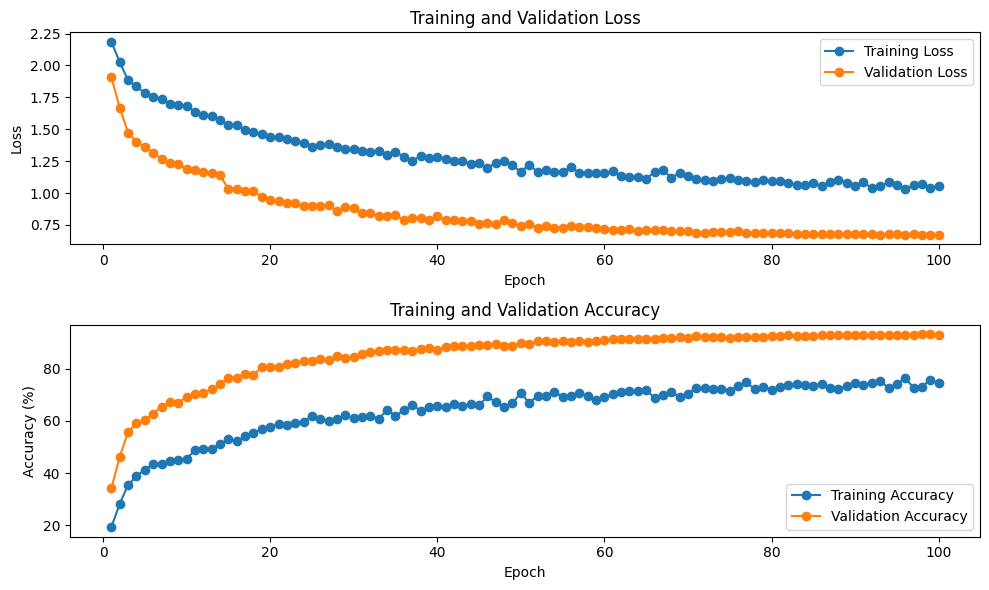

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
data = pd.read_csv("/content/gdrive/MyDrive/save_finetuned/vit-Base--CIFAR10-LR[0.001]-Seed0/log.csv")

# Extract columns from the DataFrame
epochs = range(1, len(data) + 1)
training_loss = data['T Loss']
training_accuracy = data['T Top-1']
validation_loss = data['V Loss']
validation_accuracy = data['V Top-1']

# Plotting
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(epochs, training_loss, label='Training Loss', marker='o')
plt.plot(epochs, validation_loss, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, training_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, validation_accuracy, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
